<a href="https://colab.research.google.com/github/Hui0223/pytorch-deep-learning/blob/main/04_pytorch_custom_datasets_video.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**04. PyTorch Custom Datasets**

0. Importing PyTorch and setting up device-agnostic code

In [1]:
import torch
from torch import nn

torch.__version__

'2.11.0+cu128'

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

1. Get data

Food101 dataset

Instead of 101 food classes though, we're going to start with 3: pizza, steak and sushi.

And instead of 1,000 images per class, we're going to start with a random 10% (start small, increase when necessary).


In [3]:
import requests
import zipfile
from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it and prepare it...
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)

# Download pizza, steak, sushi data
with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
  request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
  print("Downloading pizza, steak, sushi data...")
  f.write(request.content)

# Unzip pizza, steak, sushi data
with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
  print("Unzipping pizza, steak, sushi data...")
  zip_ref.extractall(image_path)

Did not find data/pizza_steak_sushi directory, creating one...
Unzipping pizza, steak, sushi data...


2. Become one with the data (data preparation)

In [4]:
import os

def walk_through_dir(dir_path):
  for dir_path,dirnames,filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dir_path}'.")

In [5]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'.
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'.
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'.
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'.
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'.
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'.
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'.


In [6]:
# Setup train and testing paths
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

**2.1 Visualize an image**

Let's write some code to:

1. Get all of the image paths using pathlib.Path.glob() to find all of the files ending in .jpg.

2. Pick a random image path using Python's random.choice().

3. Get the image class name using pathlib.Path.parent.stem.

4. And since we're working with images, we'll open the random image path using PIL.Image.open() (PIL stands for Python Image Library).

5. We'll then show the image and print some metadata.

Random image path: data/pizza_steak_sushi/train/sushi/700405.jpg
Image class:sushi
Image height:384
Image width:512


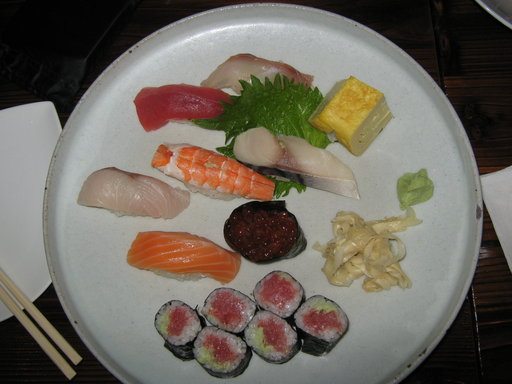

In [7]:
import random
from PIL import Image

# Set seed
random.seed(42)

# 1. Get all image paths (* means "any combination")
image_path_list = list(image_path.glob("*/*/*.jpg"))

# 2. Get random image path
random_image_path = random.choice(image_path_list)


# 3. Get image class from path name (the image class is the name of the directory where the image is stored)
image_class = random_image_path.parent.stem

# 4. Open image
img = Image.open(random_image_path)

# 5. Print metadata
print(f"Random image path: {random_image_path}")
print(f"Image class:{image_class}")
print(f"Image height:{img.height}")
print(f"Image width:{img.width}")

img


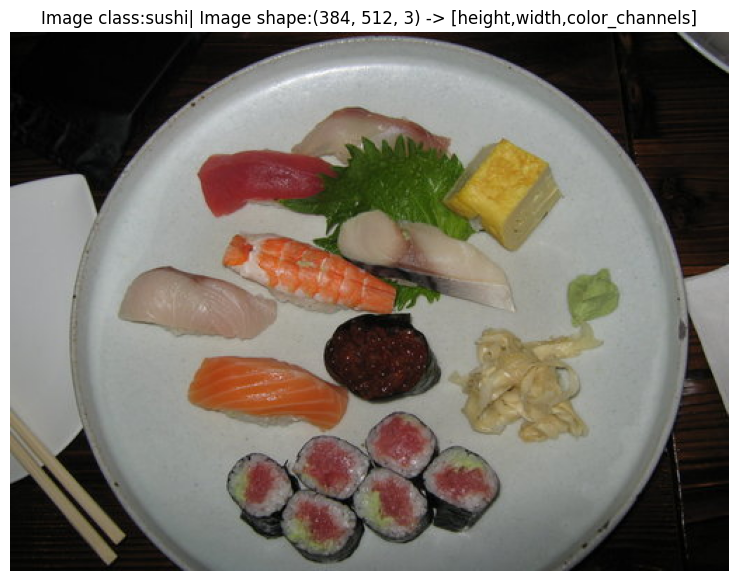

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Turn the image into an array
img_as_array = np.asarray(img)

# Plot the image with matplotlib
plt.figure(figsize=(10,7))
plt.imshow(img_as_array)
plt.title(f"Image class:{image_class}| Image shape:{img_as_array.shape} -> [height,width,color_channels]")
plt.axis(False);

**3. Transforming data**

Before we can use our image data with PyTorch we need to:

* Turn it into tensors (numerical representations of our images).

* Turn it into a torch.utils.data.Dataset and subsequently a torch.utils.data.DataLoader, we'll call these Dataset and DataLoader for short.

There are several different kinds of pre-built datasets and dataset loaders for PyTorch, depending on the problem you're working on.

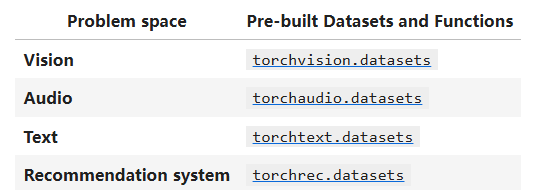

Since we're working with a vision problem, we'll be looking at torchvision.datasets for our data loading functions as well as torchvision.transforms for preparing our data.

In [9]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

3.1 Transforming data with torchvision.transforms

To get experience with torchvision.transforms, let's write a series of transform steps that:

* Resize the images using transforms.Resize() (from about 512x512 to 64x64, the same shape as the images on the CNN Explainer website).

* Flip our images randomly on the horizontal using transforms.RandomHorizontalFlip() (this could be considered a form of data augmentation because it will artificially change our image data).

* Turn our images from a PIL image to a PyTorch tensor using transforms.ToTensor().

In [10]:
# Write transform for image
data_transform = transforms.Compose([
  # Resize the images to 64x64
  transforms.Resize(size=(64,64)),
  # Flip the images randomly on the horizontal
  transforms.RandomHorizontalFlip(p=0.5), # p = probability of flip, 0.5 = 50% chance
  # Turn the image into a torch.Tensor
  transforms.ToTensor()
])

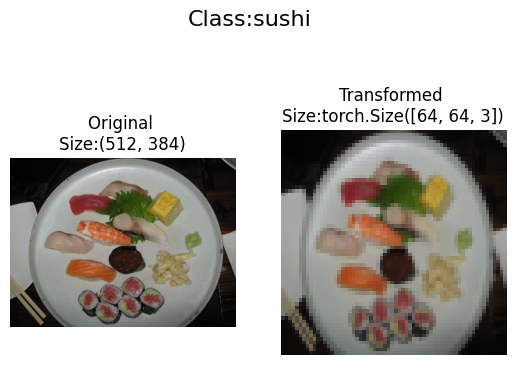

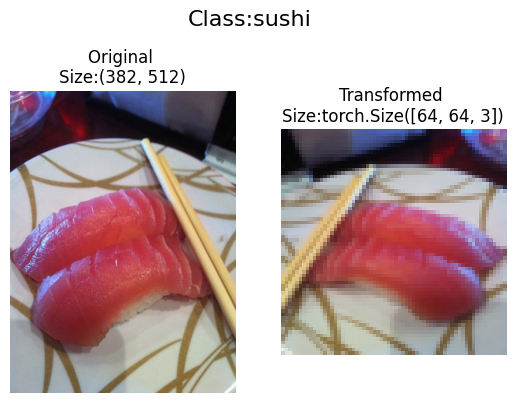

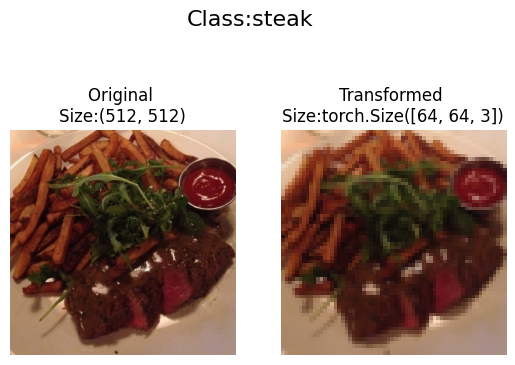

In [11]:
def plot_transformed_images(image_paths, transform, n=3, seed=42):
  random.seed(42)
  random_image_paths = random.sample(image_paths,k=n)
  for image_path in random_image_paths:
    with Image.open(image_path) as f:
      fig, ax = plt.subplots(1,2)
      ax[0].imshow(f)
      ax[0].set_title(f"Original \nSize:{f.size}")
      ax[0].axis("off")

      # Transform and plot image
      transformed_image = transform(f).permute(1,2,0) # (PyTorch default is [C, H, W] but Matplotlib is [H, W, C])
      ax[1].imshow(transformed_image)
      ax[1].set_title(f"Transformed \nSize:{transformed_image.shape}")
      ax[1].axis("off")

      fig.suptitle(f"Class:{image_path.parent.stem}",fontsize=16)

plot_transformed_images(image_path_list,
            transform=data_transform,
            n=3)


In [12]:
image_path

PosixPath('data/pizza_steak_sushi')

4. Option 1: Loading Image Data Using ImageFolder

Let's test it out on our data folders train_dir and test_dir passing in transform=data_transform to turn our images into tensors.

In [13]:
# Use ImageFolder to create dataset(s)
from torchvision import datasets

train_data = datasets.ImageFolder(root=train_dir,
                  transform=data_transform,
                  target_transform=None)

test_data = datasets.ImageFolder(root=test_dir,
                  transform=data_transform)

print(f"Train data:\n{train_data}\nTest data:\n{test_data}")

Train data:
Dataset ImageFolder
    Number of datapoints: 225
    Root location: data/pizza_steak_sushi/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )
Test data:
Dataset ImageFolder
    Number of datapoints: 75
    Root location: data/pizza_steak_sushi/test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )


In [14]:
# Get class names as a list
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [15]:
# Can also get class names as a dict
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [16]:
# Check the lengths
len(train_data),len(test_data)

(225, 75)

In [17]:
img, label = train_data[0][0], train_data[0][1]
print(f"Image tensor:\n{img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f"Label datatype: {type(label)}")

Image tensor:
tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
         [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
         [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
         ...,
         [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
         [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
         [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],

        [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
         [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
         [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
         ...,
         [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
         [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
         [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],

        [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
         [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
         [0.0196, 0.0157, 0.0157,  ..., 0.09

Original shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Image permute shape: torch.Size([64, 64, 3]) -> [height, width, color_channels]


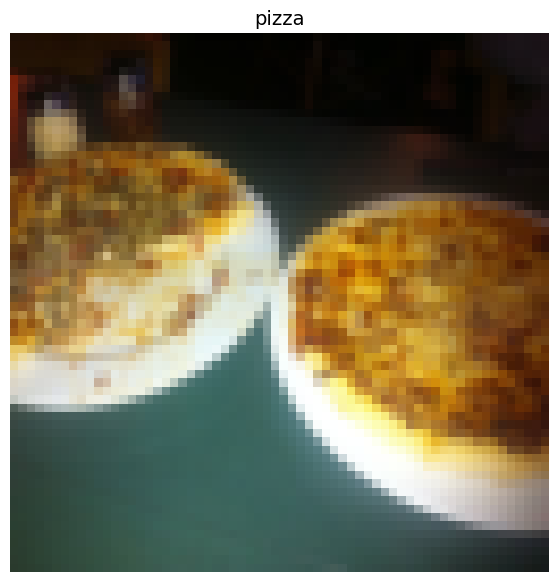

In [18]:
# Rearrange the order of dimensions
img_permute = img.permute(1,2,0)

# Print out different shapes (before and after permute)
print(f"Original shape: {img.shape} -> [color_channels, height, width]")
print(f"Image permute shape: {img_permute.shape} -> [height, width, color_channels]")

# Plot the image
plt.figure(figsize=(10,7))
plt.imshow(img.permute(1,2,0))
plt.axis("off")
plt.title(class_names[label],fontsize=14);

4.1 Turn loaded images into DataLoader's



In [21]:
# Turn train and test Datasets into DataLoaders
from torch.utils.data import DataLoader
train_dataloader = DataLoader(dataset=train_data,
                batch_size=1,
                num_workers=1,
                shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                batch_size=1,
                num_workers=1,
                shuffle=False)


train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7df0a5dbbbc0>,
 <torch.utils.data.dataloader.DataLoader at 0x7df0a6814fe0>)

In [23]:
img,label = next(iter(train_dataloader))

print(f"Image shape:{img.shape}")
print(f"Label shape:{label.shape}")

Image shape:torch.Size([1, 3, 64, 64])
Label shape:torch.Size([1])


5. Option 2: Loading Image Data with a Custom Dataset

We'll start by importing the modules we need:

* Python's os for dealing with directories (our data is stored in directories).

* Python's pathlib for dealing with filepaths (each of our images has a unique filepath).
torch for all things PyTorch.

* PIL's Image class for loading images.

* torch.utils.data.Dataset to subclass and create our own custom Dataset.

* torchvision.transforms to turn our images into tensors.

* Various types from Python's typing module to add type hints to our code.

In [25]:
import os
import pathlib
import torch
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple, Dict, List

In [27]:
train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

**5.1 Creating a helper function to get class names**

Let's write a helper function capable of creating a list of class names and a dictionary of class names and their indexes given a directory path.

To do so, we'll:

Get the class names using os.scandir() to traverse a target directory (ideally the directory is in standard image classification format).
Raise an error if the class names aren't found (if this happens, there might be something wrong with the directory structure).
Turn the class names into a dictionary of numerical labels, one for each class.

In [29]:
# Setup path for target directory
target_directory = train_dir
print(f"Target directory: {target_directory}")

# Get the class names from the target directory
class_names_found = sorted([entry.name for entry in list(os.scandir(image_path / "train"))])
print(f"Class names found: {class_names_found}")

Target directory: data/pizza_steak_sushi/train
Class names found: ['pizza', 'steak', 'sushi']


In [32]:
# Make function to find classes in target directory

def find_classes(directory:str) -> Tuple[List[str],Dict[str,int]]:
  # 1. Get the class names by scanning the target directory
  classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())

  # 2. Raise an error if class names not found
  if not classes:
    raise FileNotFoundError(f"Couldn't find any classes in {directory}.")


  # 3. Create a dictionary of index labels (computers prefer numerical rather than string labels)
  class_to_idx = {cls_name:i for i, cls_name in enumerate(classes)}
  return classes, class_to_idx


In [33]:
find_classes(train_dir)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

5.2 Create a custom Dataset to replicate ImageFolder

Let's break it down:

* Subclass torch.utils.data.Dataset.

* Initialize our subclass with a targ_dir parameter (the target data directory) and transform parameter (so we have the option to transform our data if needed).

* Create several attributes for

-- paths (the paths of our target images),

-- transform (the transforms we might like to use, this can be None),

-- classes  

-- class_to_idx (from our find_classes() function).

* Create a function to load images from file and return them, this could be using PIL or torchvision.io (for input/output of vision data).

* Overwrite the __len__ method of torch.utils.data.Dataset to return the number of samples in the Dataset, this is recommended but not required. This is so you can call len(Dataset).

* Overwrite the __getitem__ method of torch.utils.data.Dataset to return a single sample from the Dataset, this is required.

In [37]:
# Write a custom dataset class (inherits from torch.utils.data.Dataset)
from torch.utils.data import Dataset


# 1. Subclass torch.utils.data.Dataset
class ImageFolderCustom(Dataset):
  # 2. Initialize with a targ_dir and transform (optional) parameter
  def __init__(self,targ_dir:str,transform=None) -> None:
    # 3. Create class attributes
    # Get all image paths
    self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg"))
    # Setup transforms
    self.transform = transform
    # Create classes and class_to_idx attributes
    self.classes, self.class_to_idx = find_classes(targ_dir)

  # 4. Make function to load images
  def load_image(self,index:int) -> Image.Image:
    image_path = self.paths[index]
    return Image.open(image_path)

  # 5. Overwrite the __len__() method (optional but recommended for subclasses of torch.utils.data.Dataset)
  def __len__(self) -> int:
    return len(self.paths)

  # 6. Overwrite the __getitem__() method (required for subclasses of torch.utils.data.Dataset)
  def __getitem__(self,index:int) -> Tuple[torch.Tensor, int]:
    img = self.load_image(index)
    class_name = self.paths[index].parent.name
    class_idx = self.class_to_idx[class_name]

    if self.transform:
      return self.transform(img), class_idx
    else:
      return img,class_idx

In [38]:
# Augment train data
train_transforms = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

test_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

In [39]:
train_data_custom = ImageFolderCustom(targ_dir=train_dir,
                    transform=train_transforms)

test_data_custom = ImageFolderCustom(targ_dir=test_dir,
                    transform=test_transforms)
train_data_custom, test_data_custom

(<__main__.ImageFolderCustom at 0x7df0a577f3e0>,
 <__main__.ImageFolderCustom at 0x7df0a64a8140>)

In [40]:
len(train_data_custom),len(test_data_custom)

(225, 75)

In [41]:
train_data_custom.classes

['pizza', 'steak', 'sushi']

In [42]:
train_data_custom.class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [43]:
# Check for equality amongst our custom Dataset and ImageFolder Dataset
print((len(train_data_custom) == len(train_data)) & (len(test_data_custom) == len(test_data)))
print(train_data_custom.classes == train_data.classes)
print(train_data_custom.class_to_idx == train_data.class_to_idx)

True
True
True


5.3 Create a function to display random images

Specifically, it'll:

* Take in a Dataset and a number of other parameters such as classes (the names of our target classes), the number of images to display (n) and a random seed.

* To prevent the display getting out of hand, we'll cap n at 10 images.

* Set the random seed for reproducible plots (if seed is set).

* Get a list of random sample indexes (we can use Python's random.sample() for this) to plot.

* Setup a matplotlib plot.

* Loop through the random sample indexes found in step 4 and plot them with matplotlib.

* Make sure the sample images are of shape HWC (height, width, color channels) so we can plot them.

In [44]:
# 1. Take in a Dataset as well as a list of class names
def display_random_images(dataset:torch.utils.data.dataset.Dataset,
              classes:List[str]=None,
              n:int=10,
              display_shape:bool=True,
              seed:int=None):
  # 2. Adjust display if n too high
  if n > 10:
    n = 10
    display_shape = False
    print(f"For display purposes, n shouldn't be larger than 10, setting to 10 and removing shape display.")
  # 3. Set random seed
  if seed:
    random.seed(seed)

  # 4. Get random sample indexes
  random_samples_idx = random.sample(range(len(dataset)),k=n)

  # 5. Setup plot
  plt.figure(figsize=(16,8))

  # 6. Loop through samples and display random samples
  for i, targ_sample in enumerate(random_samples_idx):
    targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]
    # 7. Adjust image tensor shape for plotting: [color_channels, height, width] -> [color_channels, height, width]
    targ_image_adjust = targ_image.permute(1, 2, 0)

    # Plot adjusted samples
    plt.subplot(1, n, i+1)
    plt.imshow(targ_image_adjust)
    plt.axis("off")
    if classes:
      title = f"class: {classes[targ_label]}"
      if display_shape:
        title = title + f"\nshape: {targ_image_adjust.shape}"
    plt.title(title)

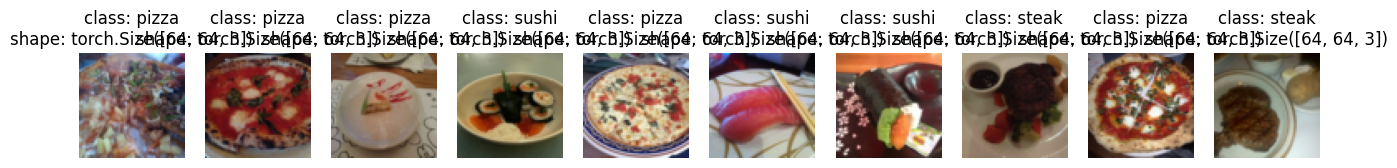

In [45]:
# Display random images from ImageFolder created Dataset
display_random_images(
    train_data,
    n=10,
    classes=class_names,
    seed=None
)

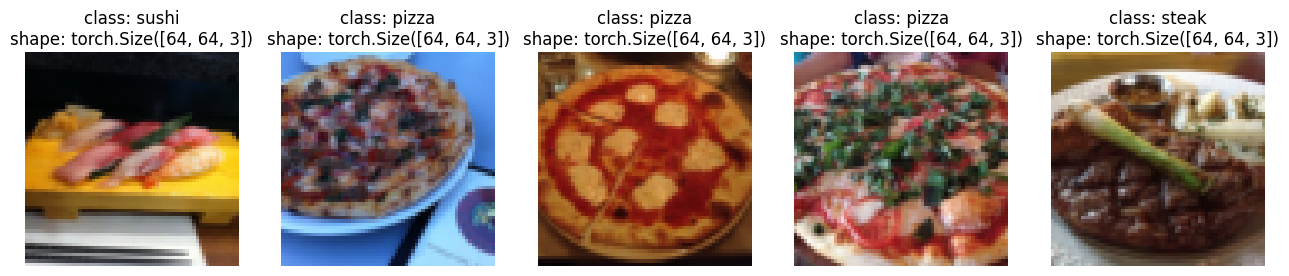

In [47]:
# Display random images from ImageFolderCustom Dataset
display_random_images(train_data_custom,
          n=5,
          classes=class_names,
          seed=None)

5.4 Turn custom loaded images into DataLoader's